In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.metrics import roc_curve, auc
import helper

In [2]:
df = helper.prepare_data()

In [6]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
class DecisionNode:
  def __init__(self, impurity=None, feature_index=None, threshold=None, left=None, right=None):
    self.left = left
    self.right = right
    # The largest impurity value of this node
    self.impurity = impurity
    # Index of the feature which make the best fit for this node.
    self.feature_index = feature_index
    # The threshold value for that feature to make the split.
    self.threshold = threshold

class LeafNode:
  def __init__(self, value):
    self.prediction_value = value

class DecisionTreeClassifierFromScratch:
  def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.root = None
    self.min_sample_split = min_sample_split
    self.min_impurity = min_impurity
    self.max_depth = max_depth
    self.impurity_function = self._calculate_information_gain
    if criterion == 'entropy':
      self.criterion = self._entropy
      self.criterion_name = criterion
    else:
      self.criterion = self._gini_index
      self.criterion_name = 'gini'

  def _gini_index(self, y):
    gini = 1
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      gini += -np.square(p)
    return gini

  def _entropy(self, y):
    entropy = 0
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      entropy += -p * np.log2(p)
    return entropy

  def _calculate_information_gain(self, y, y1, y2):
    # :param y: target value.
    # :param y1: target value for dataset in the true split/right branch.
    # :param y2: target value for dataset in the false split/left branch.

    # propobility of true values.
    p = len(y1) / len(y)
    info_gain = self.criterion(y) - p * self.criterion(y1) - (1 - p) * self.criterion(y2)
    return info_gain

  def _leaf_value_calculation(self, y):
    most_frequent_label = None
    max_count = 0
    unique_labels = np.unique(y)
    # iterate over all the unique values and find their frequentcy count.
    for label in unique_labels:
      count = len( y[y == label])
      if count > max_count:
        most_frequent_label = label
        max_count = count
    return most_frequent_label

  def _partition_dataset(self, Xy, feature_index, threshold):
    col = Xy[:, feature_index]
    X_1 = Xy[col >= threshold]
    X_2 = Xy[col < threshold]

    return X_1, X_2

  def _find_best_split(self, Xy):
    best_question = tuple()
    best_datasplit = {}
    largest_impurity = 0
    n_features = (Xy.shape[1] - 1)
    # iterate over all the features.
    for feature_index in range(n_features):
      # find the unique values in that feature.
      unique_value = set(s for s in Xy[:,feature_index])
      # iterate over all the unique values to find the impurity.
      for threshold in unique_value:
        # split the dataset based on the feature value.
        true_xy, false_xy = self._partition_dataset(Xy, feature_index, threshold)

        # skip the node which has any on type 0. because this means it is already pure.
        if len(true_xy) > 0 and len(false_xy) > 0:
          # find the y values.
          y = Xy[:, -1]
          true_y = true_xy[:, -1]
          false_y = false_xy[:, -1]
          # calculate the impurity function.
          impurity = self.impurity_function(y, true_y, false_y)

          # if the calculated impurity is larger than save this value for comaparison (highest gain).
          if impurity > largest_impurity:
            largest_impurity = impurity
            best_question = (feature_index, threshold)
            best_datasplit = {
              "leftX": true_xy[:, :n_features],   # X of left subtree
              "lefty": true_xy[:, n_features:],   # y of left subtree
              "rightX": false_xy[:, :n_features],  # X of right subtree
              "righty": false_xy[:, n_features:]   # y of right subtree
            }

    return largest_impurity, best_question, best_datasplit

  def _build_tree(self, X, y, current_depth=0):
    n_samples , n_features = X.shape
    # Add y as last column of X
    Xy = np.column_stack((X, y))
    # find the Information gain on each feature each values and return the question which splits the data very well
    if (n_samples >= self.min_sample_split) and (current_depth < self.max_depth):
      # find the best split/ which question split the data well.
      impurity, question, best_datasplit = self._find_best_split(Xy)
      if impurity > self.min_impurity:
        # Build subtrees for the right and left branch.
        true_branch = self._build_tree(best_datasplit["leftX"], best_datasplit["lefty"], current_depth + 1)
        false_branch = self._build_tree(best_datasplit["rightX"], best_datasplit["righty"], current_depth + 1)
        return DecisionNode(impurity=impurity, feature_index=question[0], threshold=question[1],
                            left=true_branch, right=false_branch)

    leaf_value = self._leaf_value_calculation(y)
    return LeafNode(value=leaf_value)

  def fit(self, X, y):
    self.root = self._build_tree(X, y, current_depth=0)

  def predict_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_sample(x, branch)

  def predict(self, test_X):
    x = np.array(test_X)
    y_pred = [self.predict_sample(sample) for sample in x]
    y_pred = np.array(y_pred)
    return y_pred

  def predict_proba_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_proba_sample(x, branch)
  
  def predict_proba(self, test_X):
    x = np.array(test_X)
    y_pred_proba = [self.predict_proba_sample(sample) for sample in x]
    y_pred_proba = np.array(y_pred_proba)
    return y_pred_proba

  def draw_tree(self):
    self._draw_tree(self.root)

  def _draw_tree(self, tree = None, indentation = " ", depth=0):
    if isinstance(tree , LeafNode):
      print(indentation,"The predicted value -->", tree.prediction_value)
      return
    else:
      print(indentation,f"({depth}) Is {tree.feature_index}>={tree.threshold}?"
            f": {self.criterion_name}:{tree.impurity:.2f}")
      if tree.left is not None:
          print (indentation + '----- True branch :)')
          self._draw_tree(tree.left, indentation + "  ", depth+1)
      if tree.right is not None:
          print (indentation + '----- False branch :)')
          self._draw_tree(tree.right, indentation + "  ", depth+1)

Accuracy: 0.7237607310994184
Confusion Matrix:


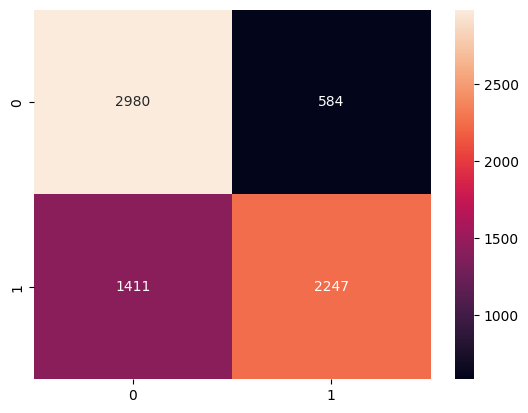

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      3564
           1       0.79      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



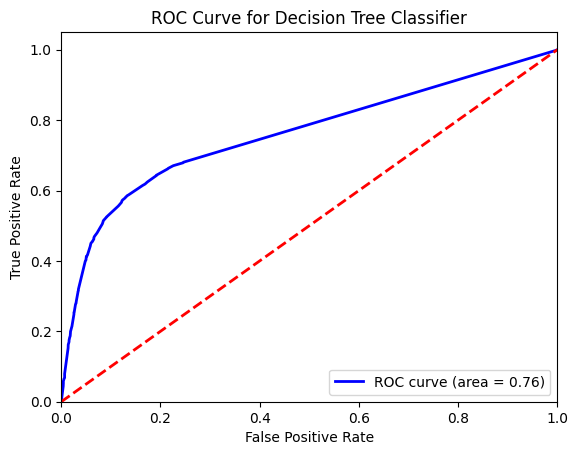

In [7]:
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7237607310994184
Confusion Matrix:


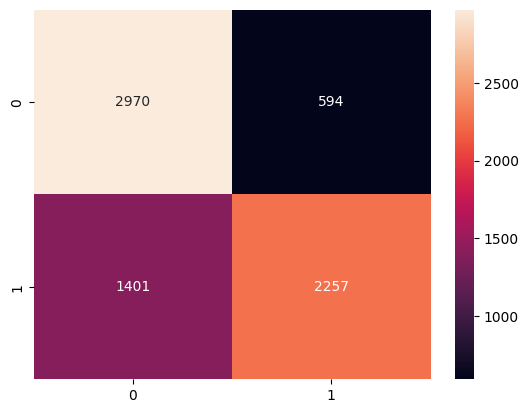

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



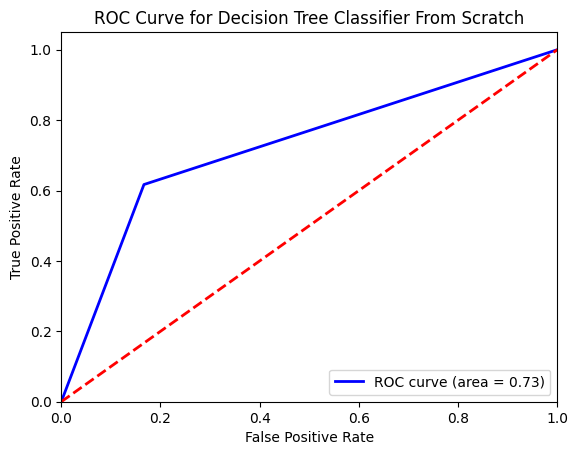

In [8]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='gini')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

Accuracy: 0.7240376626973137
Confusion Matrix:


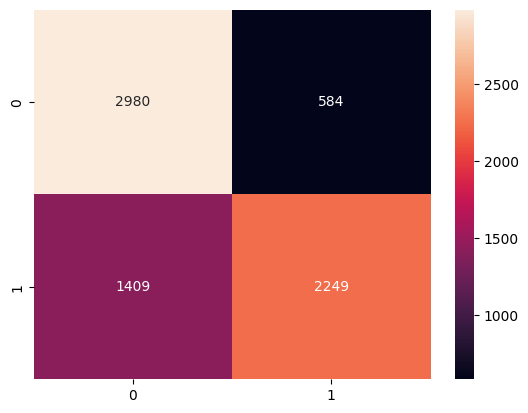

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      3564
           1       0.79      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



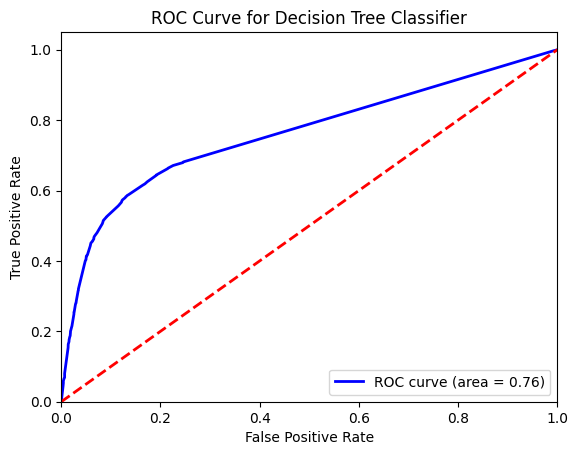

In [9]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7238991968983661
Confusion Matrix:


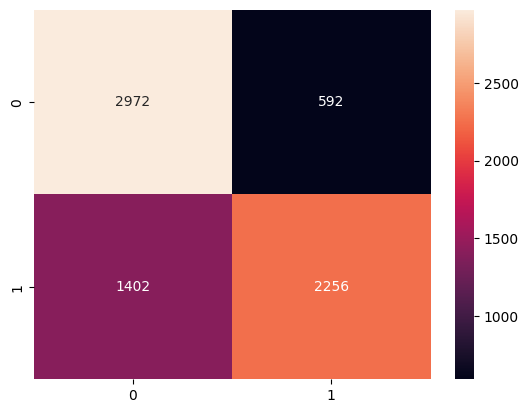

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



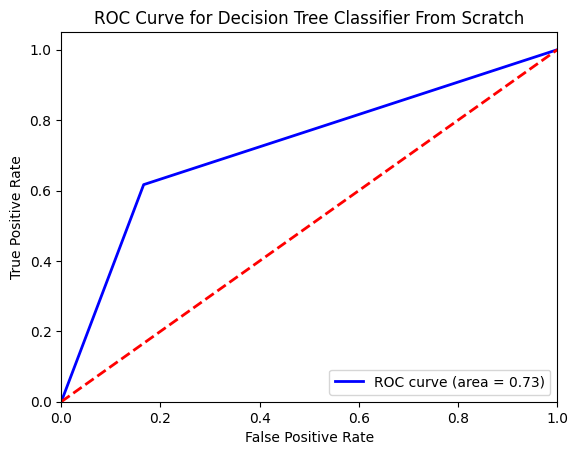

In [10]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='entropy')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.7817832764505119
Confusion Matrix:


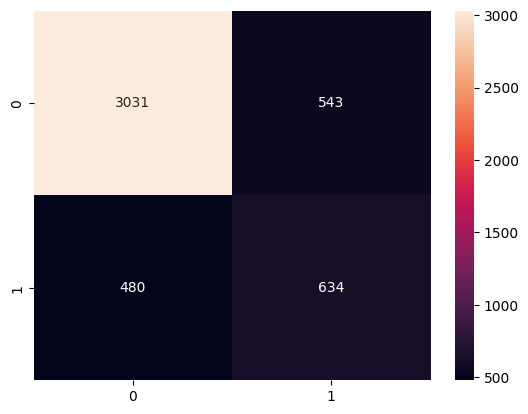

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3574
           1       0.54      0.57      0.55      1114

    accuracy                           0.78      4688
   macro avg       0.70      0.71      0.70      4688
weighted avg       0.79      0.78      0.78      4688



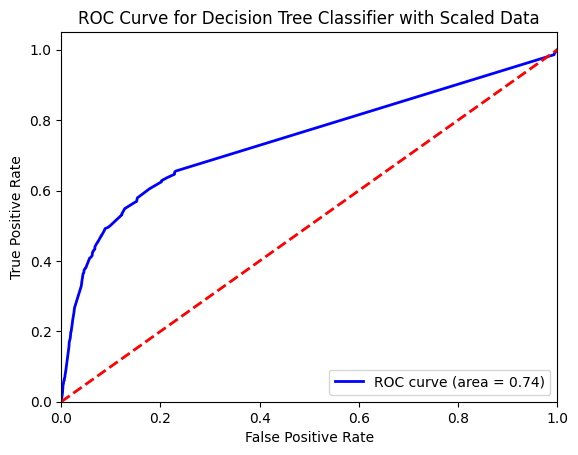

In [8]:
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier with Scaled Data")

Accuracy: 0.7824232081911263
Confusion Matrix:


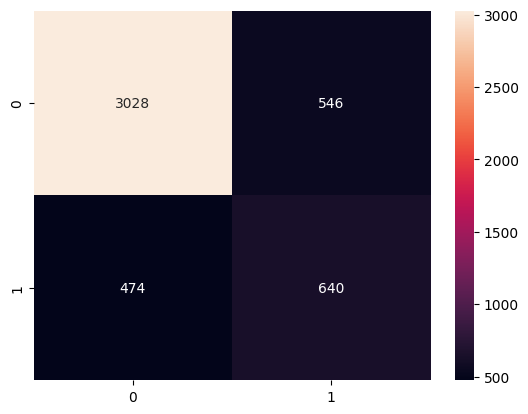

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3574
           1       0.54      0.57      0.56      1114

    accuracy                           0.78      4688
   macro avg       0.70      0.71      0.71      4688
weighted avg       0.79      0.78      0.78      4688



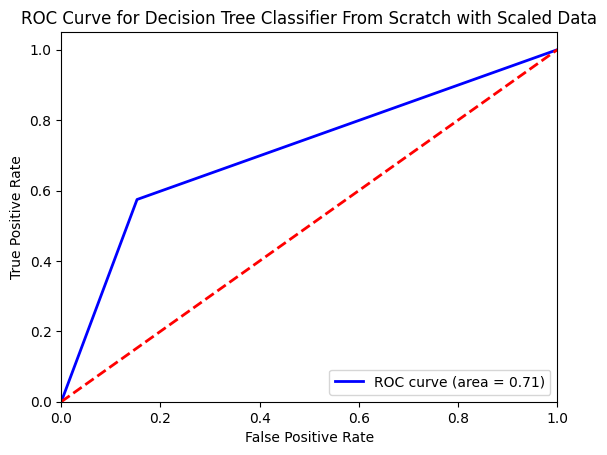

In [9]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='gini')
model_scratch.fit(X_train_scaled, y_train)
y_pred = model_scratch.predict(X_test_scaled)
y_pred_proba = model_scratch.predict_proba(X_test_scaled)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier From Scratch with Scaled Data")